# Практическая работа №4
## Сравнение наборов признаков и выбор модели

Цель работы: обучить базовую линейную модель, проверить мультиколлинеарность признаков, удалить избыточные признаки, сравнить модели и проанализировать остатки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/medical_insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [ ]:
X = df.drop(columns=["charges"])
y = df["charges"]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("X:", X.shape)
print("y:", y.shape)

NameError: name 'X' is not defined

In [3]:
df.shape

NameError: name 'df' is not defined

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df.shape

NameError: name 'df' is not defined

In [6]:
import pandas as pd

df = pd.read_csv("../data/medical_insurance.csv")

In [7]:
df.shape

(1338, 7)

In [8]:
X = df.drop(columns=["charges"])
y = df["charges"]

In [9]:
print("X:", X.shape)
print("y:", y.shape)

X: (1338, 6)
y: (1338,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1070, 6)
X_test: (268, 6)
y_train: (1070,)
y_test: (268,)


In [11]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [13]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [15]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [16]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [17]:
y_pred_base = baseline_model.predict(X_test)

In [18]:
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("BASELINE MODEL")
print(f"MAE:  {mae_base:.2f}")
print(f"RMSE: {rmse_base:.2f}")
print(f"R²:   {r2_base:.3f}")

BASELINE MODEL
MAE:  4181.19
RMSE: 5796.28
R²:   0.784


In [19]:
numeric_df = df[["age", "bmi", "children"]]

correlation_matrix = numeric_df.corr()

correlation_matrix

,age,bmi,children
age,1.000000,0.109272,0.042469
bmi,0.109272,1.000000,0.012759
children,0.042469,0.012759,1.000000


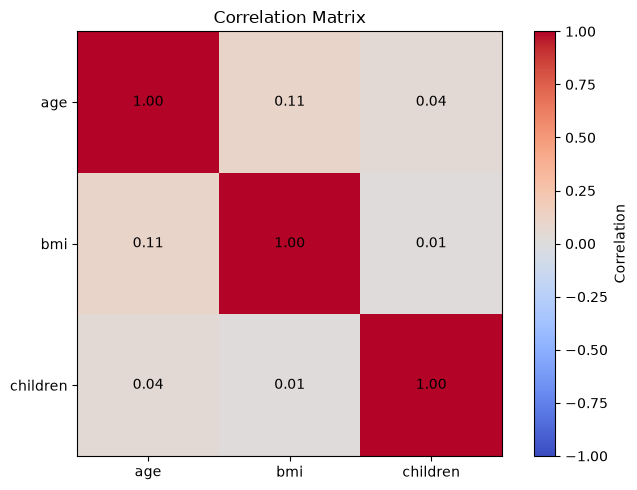

In [20]:
plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Сокращённый набор признаков

Корреляционная матрица не показала сильной мультиколлинеарности между числовыми признаками. Для проверки влияния сокращения набора признаков из модели исключён признак `children`. Далее результаты сокращённой модели сравниваются с базовой.

In [21]:
numeric_features_reduced = ["age", "bmi"]
categorical_features_reduced = ["sex", "smoker", "region"]

print("Числовые:", numeric_features_reduced)
print("Категориальные:", categorical_features_reduced)

Числовые: ['age', 'bmi']
Категориальные: ['sex', 'smoker', 'region']


In [22]:
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_reduced),
        ("cat", categorical_transformer, categorical_features_reduced)
    ]
)

In [23]:
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_reduced),
        ("cat", categorical_transformer, categorical_features_reduced)
    ]
)

In [24]:
reduced_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reduced),
    ("model", LinearRegression())
])

In [25]:
reduced_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [26]:
y_pred_reduced = reduced_model.predict(X_test)

In [27]:
print("Количество предсказаний:", len(y_pred_reduced))
print("Количество test объектов:", len(y_test))

Количество предсказаний: 268
Количество test объектов: 268


In [28]:
mae_reduced = mean_absolute_error(y_test, y_pred_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test, y_pred_reduced))
r2_reduced = r2_score(y_test, y_pred_reduced)

In [29]:
print("BASELINE MODEL")
print(f"MAE:  {mae_base:.2f}")
print(f"RMSE: {rmse_base:.2f}")
print(f"R²:   {r2_base:.3f}")

print("\nREDUCED MODEL")
print(f"MAE:  {mae_reduced:.2f}")
print(f"RMSE: {rmse_reduced:.2f}")
print(f"R²:   {r2_reduced:.3f}")

BASELINE MODEL
MAE:  4181.19
RMSE: 5796.28
R²:   0.784

REDUCED MODEL
MAE:  4222.91
RMSE: 5843.15
R²:   0.780


### Сравнение моделей

Базовая модель показала немного лучшие результаты, чем сокращённая модель.

MAE базовой модели показывает, что прогноз стоимости страховки в среднем отличается от истинного значения примерно на 4181 денежную единицу.

RMSE составляет примерно 5796 денежных единиц. Значение RMSE выше MAE, поскольку эта метрика сильнее штрафует крупные ошибки.

R² = 0.784 означает, что модель объясняет примерно 78.4% вариации стоимости страховки на тестовой выборке.

После удаления признака `children` MAE и RMSE немного увеличились, а R² уменьшился. Следовательно, удаление этого признака не улучшило качество модели.

In [30]:
residuals = y_test - y_pred_base

In [31]:
residuals.head()

764      125.517976
887    -1796.571643
890    -7527.427762
1293    -152.784951
259     6777.118343
Name: charges, dtype: float64

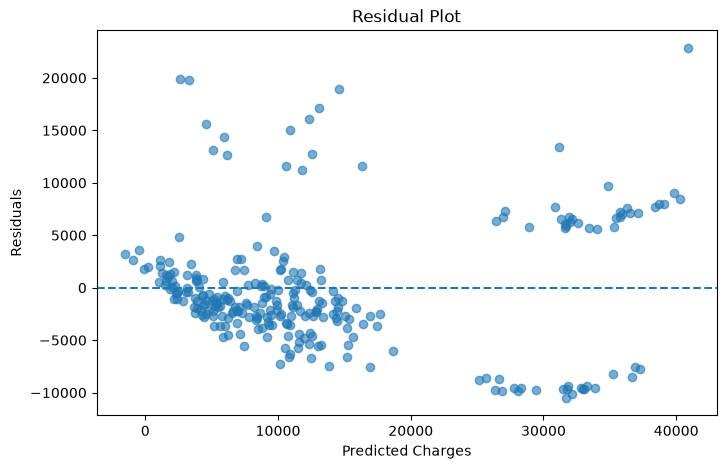

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_base, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Анализ остатков

Остатки расположены относительно нулевой линии, однако присутствует некоторый разброс и отдельные крупные ошибки. Если выраженного систематического паттерна не наблюдается, линейная модель в целом описывает основную зависимость, хотя для части наблюдений ошибки остаются значительными.

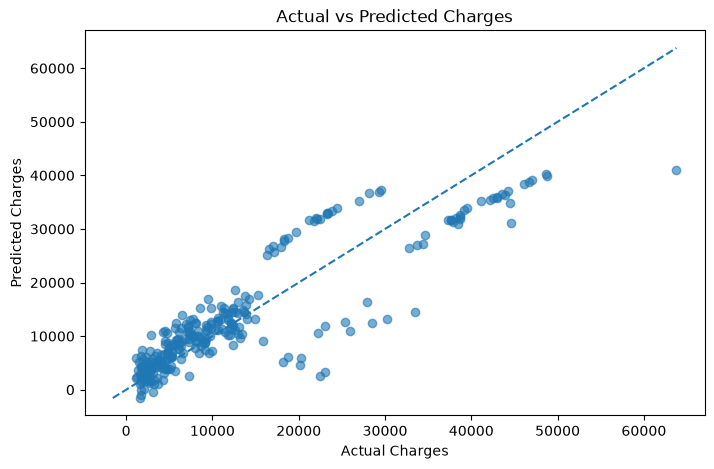

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_base, alpha=0.6)

min_value = min(y_test.min(), y_pred_base.min())
max_value = max(y_test.max(), y_pred_base.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

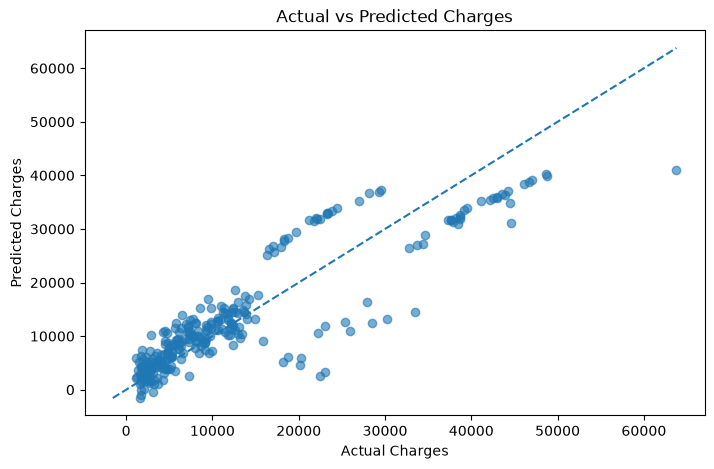

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_base, alpha=0.6)

min_value = min(y_test.min(), y_pred_base.min())
max_value = max(y_test.max(), y_pred_base.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

### Предсказанные и реальные значения

Диагональная линия соответствует идеальному случаю, когда предсказанное значение полностью совпадает с истинным. Большинство наблюдений располагаются относительно близко к линии, однако присутствуют случаи со значительными ошибками прогнозирования.

## Вывод

В работе была построена линейная регрессионная модель для прогнозирования стоимости медицинской страховки (`charges`).

Для предобработки данных использовался Pipeline/ColumnTransformer из предыдущей практической работы. Числовые признаки масштабировались, категориальные признаки кодировались с помощью OneHotEncoder, а обработка обучалась только на тренировочной выборке.

Сначала была обучена базовая модель с использованием всех доступных признаков. Проверка корреляционной матрицы не выявила сильной мультиколлинеарности между числовыми признаками.

Для эксперимента был создан сокращённый набор признаков без `children` и обучена вторая модель.

Базовая модель:
- MAE ≈ 4181 денежных единиц;
- RMSE ≈ 5796 денежных единиц;
- R² ≈ 0.784.

Сокращённая модель:
- MAE ≈ 4223 денежных единиц;
- RMSE ≈ 5843 денежных единиц;
- R² ≈ 0.780.

После удаления признака `children` качество модели немного ухудшилось: MAE и RMSE увеличились, а R² уменьшился. Поэтому удаление данного признака не даёт преимущества.

Анализ остатков позволяет оценить ошибки модели и наличие систематического паттерна. График истинных и предсказанных значений также показывает, что модель достаточно хорошо описывает общую зависимость, хотя для некоторых наблюдений присутствуют значительные ошибки.

В качестве финальной модели выбрана базовая модель со всеми исходными признаками, поскольку она показывает лучшие метрики на тестовой выборке, а сильная мультиколлинеарность между числовыми признаками не была обнаружена.